In [1]:
# https://www.geeksforgeeks.org/ml-expectation-maximization-algorithm/


import numpy as np
import seaborn as sns
from scipy.stats import norm
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

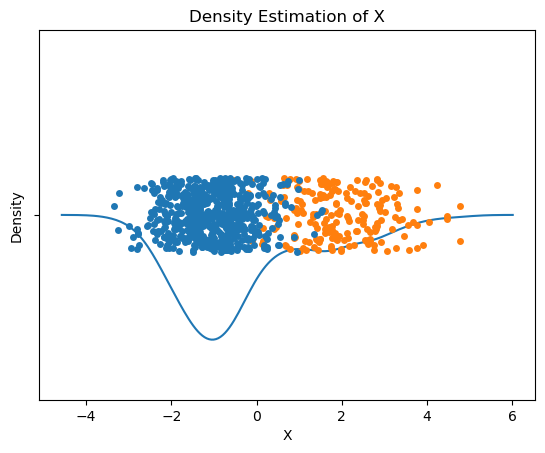

In [2]:
# Generate a dataset with two Gaussian components
mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8
X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

# Plot the density estimation using seaborn
sns.kdeplot(X)
sns.stripplot(x=X1,color='tab:orange')
sns.stripplot(x=X2,color='tab:blue')

plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()

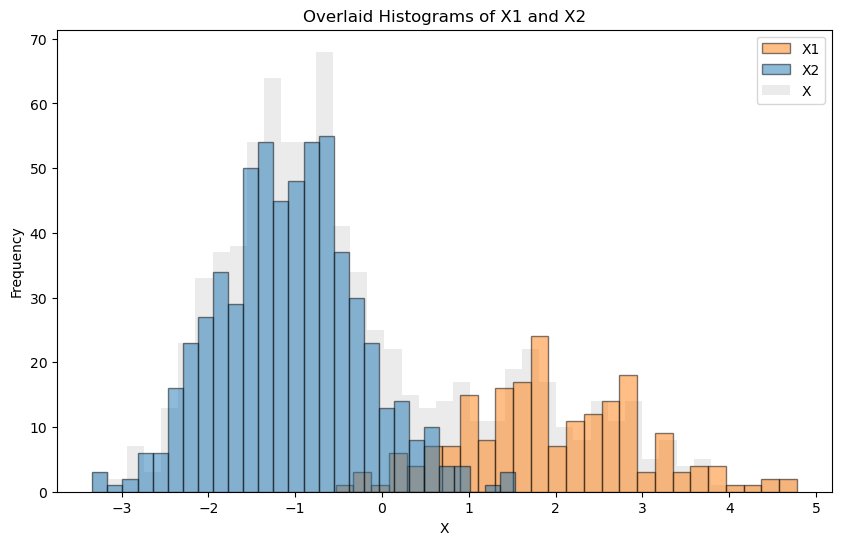

In [3]:
# Plot overlaid histograms
plt.figure(figsize=(10, 6))

plt.hist(X1, bins=26, alpha=0.5, label='X1', color='tab:orange',edgecolor='black')
plt.hist(X2, bins=28, alpha=0.5, label='X2', color='tab:blue',edgecolor='black')
plt.hist(X, bins=41, alpha=0.15, label='X', color='tab:gray',zorder=-1)
plt.xlabel('X')
plt.ylabel('Frequency')
plt.title('Overlaid Histograms of X1 and X2')
plt.legend()
plt.show()

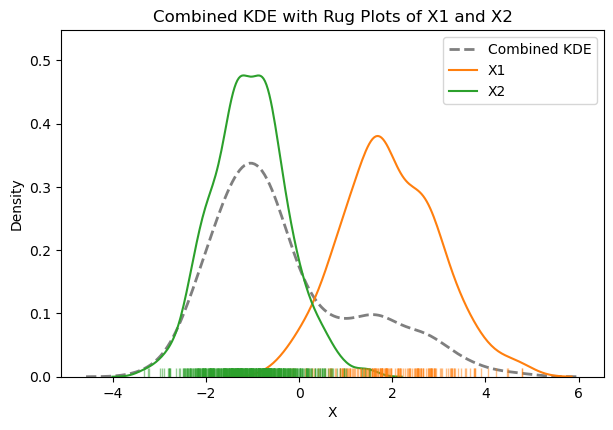

In [4]:
plt.figure(figsize=(7, 4.5))
sns.kdeplot(X, color='tab:gray', label='Combined KDE',lw=2, ls='dashed')
sns.kdeplot(X1, color='tab:orange', label='X1')
sns.kdeplot(X2, color='tab:green', label='X2')
sns.rugplot(X1, color='tab:orange', alpha=0.5)
sns.rugplot(X2, color='tab:green', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Combined KDE with Rug Plots of X1 and X2')
plt.legend()
plt.show()

In [5]:
# Initialize parameters
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)

### Perform EM algorithm

* Iterates for the specified number of epochs (20 in this case).
* In each epoch, the E-step calculates the responsibilities (gamma values) by evaluating the Gaussian probability densities for each component and weighting them by the corresponding proportions.
* The M-step updates the parameters by computing the weighted mean and standard deviation for each component

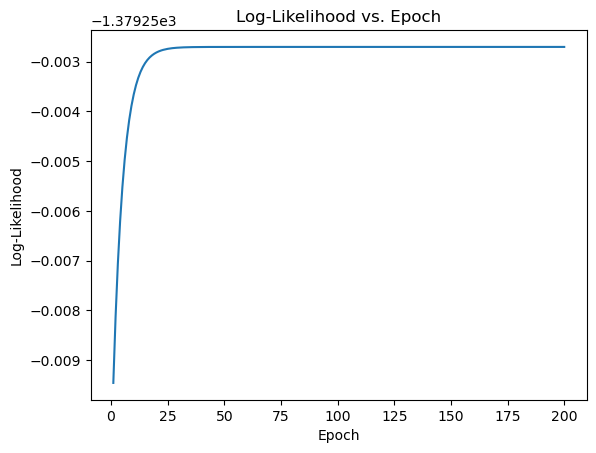

In [8]:
# Perform EM algorithm for 20 epochs
num_epochs = 200
log_likelihoods = []

for epoch in range(num_epochs):
    # E-step: Compute responsibilities
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2
    gamma1 /= total
    gamma2 /= total
    
    # M-step: Update parameters
    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)
    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat)**2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat)**2) / np.sum(gamma2))
    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)
    
    # Compute log-likelihood
    log_likelihood = np.sum(np.log(pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
                                   + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)))
    log_likelihoods.append(log_likelihood)

# Plot log-likelihood values over epochs
plt.plot(range(1, num_epochs+1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()

0.27613289599725843

In [115]:
mu1_hat, sigma1_hat, pi1_hat, mu1, sigma1, 200/800

(1.8844674043335368, 1.1357785333819306, 0.27613289599725843, 2, 1, 0.25)

In [116]:
mu2_hat, sigma2_hat, pi2_hat, mu2, sigma2, 600/800

(-1.0822730522175332, 0.7614530332448739, 0.7238671040027416, -1, 0.8, 0.75)

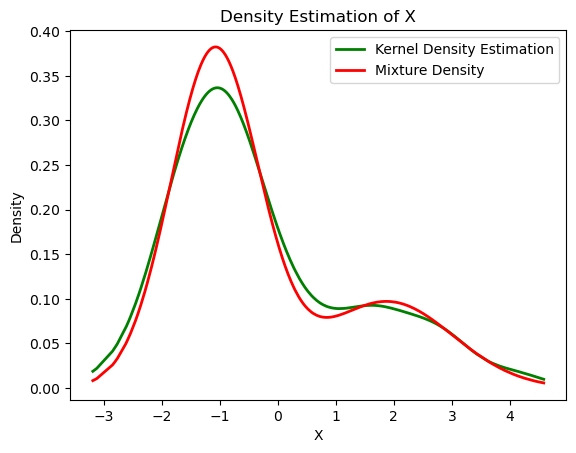

In [14]:
# Plot the final estimated density
X_sorted = np.sort(X)
density_estimation = pi1_hat*norm.pdf(X_sorted,
                                        mu1_hat, 
                                        sigma1_hat) + pi2_hat * norm.pdf(X_sorted,
                                                                         mu2_hat, 
                                                                         sigma2_hat)


plt.plot(X_sorted, gaussian_kde(X_sorted)(X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.legend(['Kernel Density Estimation','Mixture Density'])
plt.show()

-------

In [102]:
from sklearn.mixture import GaussianMixture


In [103]:
# Seed for reproducibility
np.random.seed(42)

# Generate data with 2 Gaussian components
mu1, sigma1, size1 = 2, 1, 200
mu2, sigma2, size2 = -1, 0.8, 600
X1 = np.random.normal(mu1, sigma1, size=size1)
X2 = np.random.normal(mu2, sigma2, size=size2)
X = np.concatenate([X1, X2]).reshape(-1, 1)

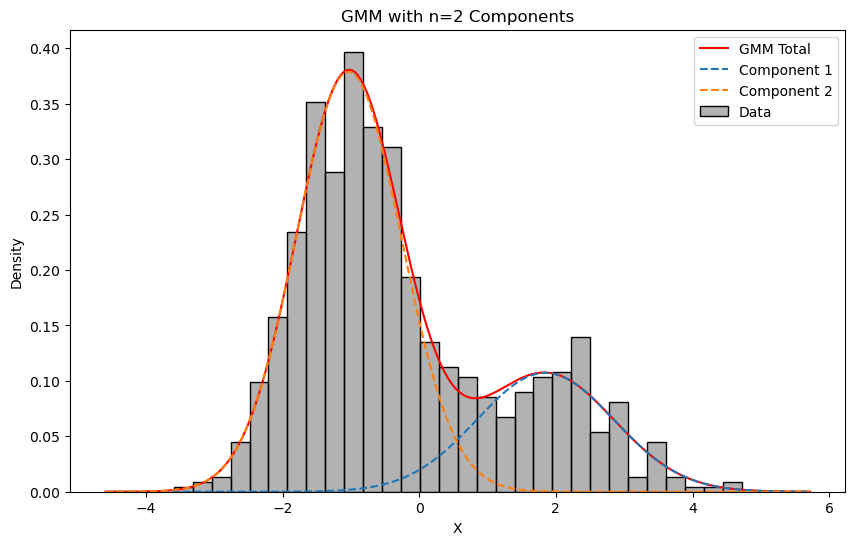

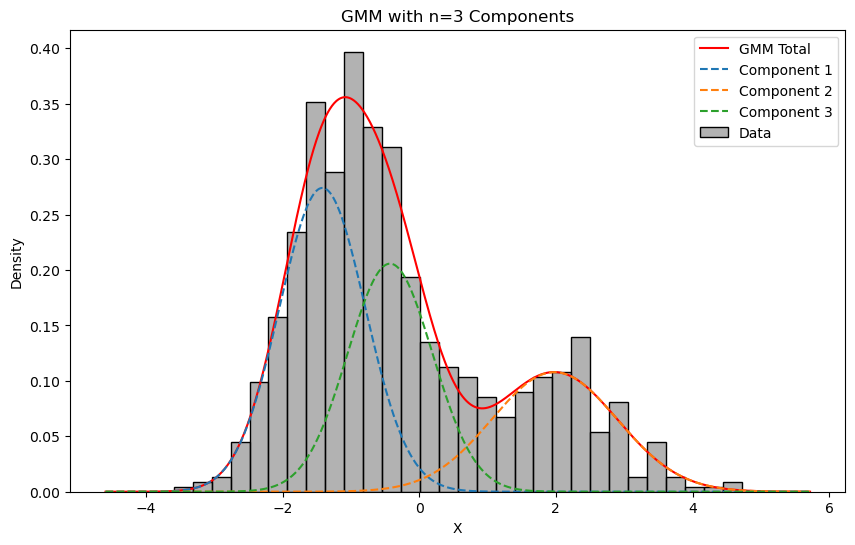

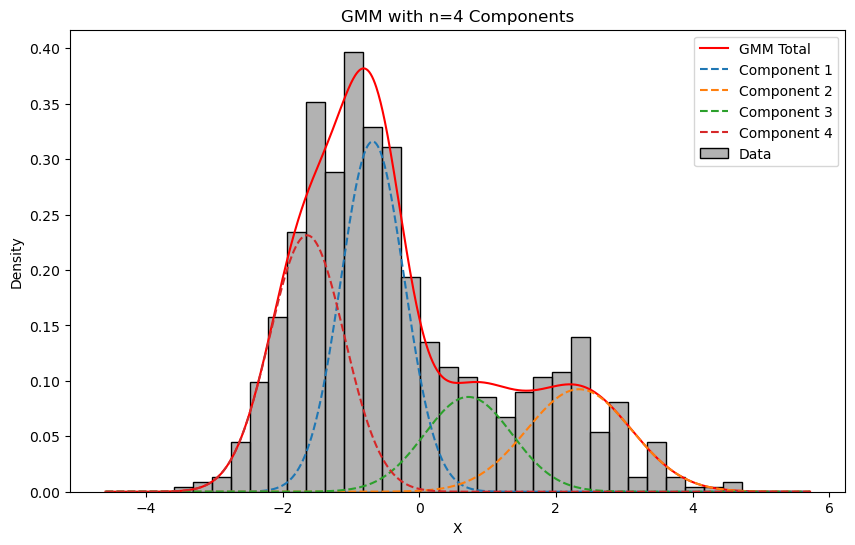

In [112]:
# Function to plot GMM results
def plot_gmm(gmm, X, title):
    plt.figure(figsize=(10, 6))
    sns.histplot(X.flatten(), bins=30, kde=False, stat='density', color='gray', alpha=0.6, label='Data')
    
    X_sorted = np.linspace(X.min()-1, X.max()+1, 1000).reshape(-1, 1)
    logprob = gmm.score_samples(X_sorted)
    pdf = np.exp(logprob)
    plt.plot(X_sorted, pdf, label='GMM Total', color='red')
    
    # Plot individual components
    for i in range(gmm.n_components):
        component_pdf = gmm.weights_[i] * norm.pdf(X_sorted, gmm.means_[i], np.sqrt(gmm.covariances_[i]))
        plt.plot(X_sorted, component_pdf, linestyle='--', label=f'Component {i+1}')
    
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

# Fit GMM with n=2
gmm2 = GaussianMixture(n_components=2, random_state=42)
gmm2.fit(X)
plot_gmm(gmm2, X, 'GMM with n=2 Components')

# Fit GMM with n=3
gmm3 = GaussianMixture(n_components=3, random_state=42)
gmm3.fit(X)
plot_gmm(gmm3, X, 'GMM with n=3 Components')


# Fit GMM with n=3
gmm4 = GaussianMixture(n_components=4, random_state=42)
gmm4.fit(X)
plot_gmm(gmm4, X, 'GMM with n=4 Components')


In [105]:
gmm2.means_

array([[ 1.84526499],
       [-1.03411266]])

In [106]:
gmm3.means_

array([[-1.41870078],
       [ 1.97912977],
       [-0.42778419]])

In [110]:
gmm4.means_

array([[-0.68252393],
       [ 2.33924036],
       [ 0.71696577],
       [-1.64234997]])

In [108]:
mu1, sigma1, mu2, sigma2

(2, 1, -1, 0.8)

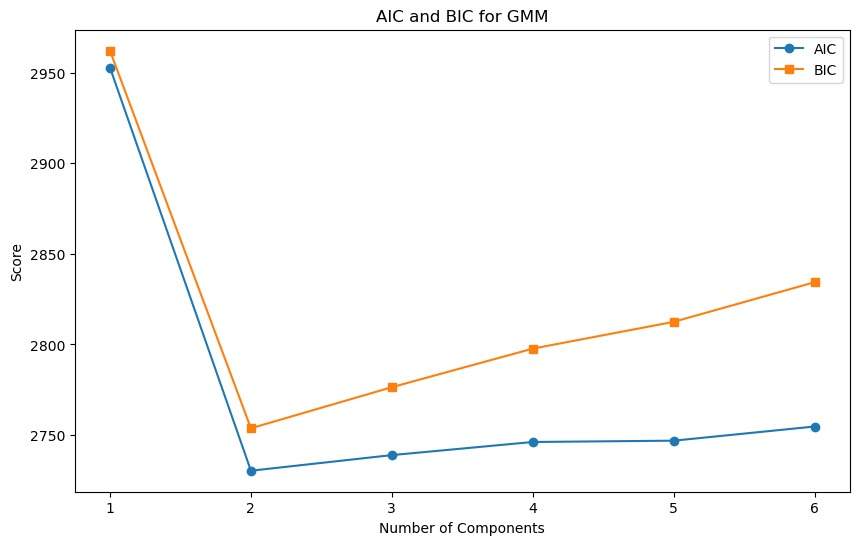

In [111]:
aic = []
bic = []
n_components = range(1, 7)

for n in n_components:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X)
    aic.append(gmm.aic(X))
    bic.append(gmm.bic(X))

plt.figure(figsize=(10, 6))
plt.plot(n_components, aic, label='AIC', marker='o')
plt.plot(n_components, bic, label='BIC', marker='s')
plt.xlabel('Number of Components')
plt.ylabel('Score')
plt.title('AIC and BIC for GMM')
plt.legend()
plt.show()